
Rodando Análise de Componentes Principais (PCA)...


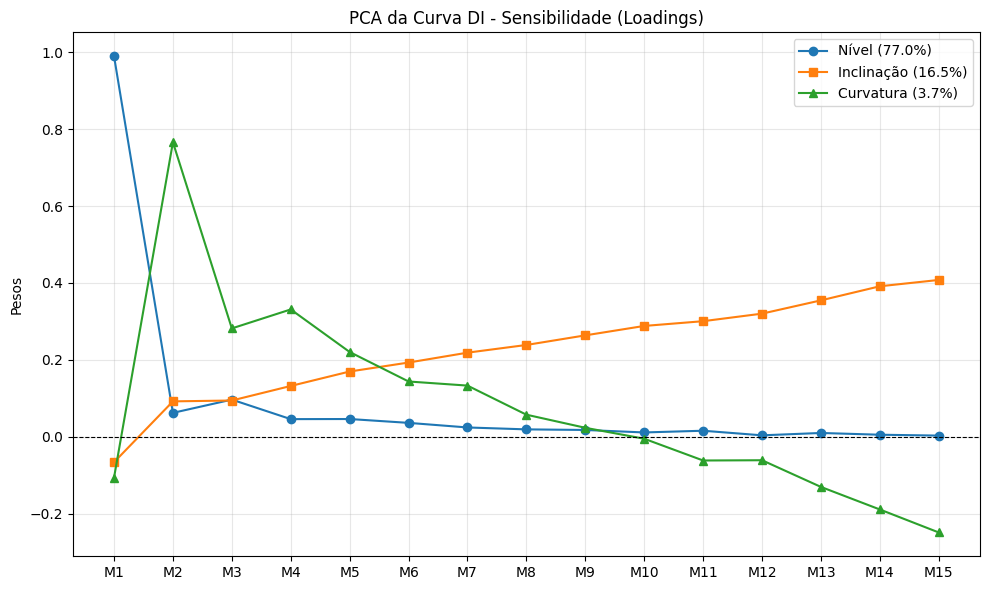

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller

df = pd.read_csv("DI_Historico_Consolidado_20210101_a_20260227.csv", sep=";")

df['Data_Referencia'] = pd.to_datetime(df['Data_Referencia'], format='%d/%m/%Y')
df['Maturity'] = pd.to_datetime(df['Maturity'], format='%d/%m/%Y')

# Calcular NDU (Dias Úteis) - Aproximação Numpy
dates_ref = df['Data_Referencia'].values.astype('datetime64[D]')
dates_mat = df['Maturity'].values.astype('datetime64[D]')
df['NDU'] = np.busday_count(dates_ref, dates_mat)
df = df[df['NDU'] > 0].copy()

# Convertendo PU para a Taxa
df['Taxa'] = ((100000.0 / df['AdjstdQt']) ** (252.0 / df['NDU']) - 1) * 100

# Ordenar e criar os vértices dinâmicos (V1, V2, V3...)
df = df.sort_values(by=['Data_Referencia', 'Maturity'])
df['Ordem'] = df.groupby('Data_Referencia').cumcount() + 1
df['Vertice'] = 'M' + df['Ordem'].astype(str)


# Pivotar a tabela (Dias nas linhas, Vértices nas colunas)
df_pivot = df.pivot(index='Data_Referencia', columns='Vertice', values='Taxa')
cols = sorted(df_pivot.columns, key=lambda x: int(x[1:]))
df_pivot = df_pivot[cols]


########### PCA #############
print("\nRodando Análise de Componentes Principais (PCA)...")
# Selecionar M1 ao M15 (evita vértices muito longos e sem liquidez)
vertices_pca = [f'M{i}' for i in range(1, 16)]
df_pca = df_pivot[vertices_pca].dropna()

# O PCA usa a VARIAÇÃO DIÁRIA (Delta y)
df_diff = df_pca.diff().dropna()

pca = PCA(n_components=3)
factors = pca.fit_transform(df_diff)
var_expl = pca.explained_variance_ratio_ * 100

# Plotar os Loadings (Gráfico 1)
loadings = pd.DataFrame(pca.components_.T, columns=['Nível', 'Inclinação', 'Curvatura'], index=vertices_pca)

plt.figure(figsize=(10, 6))
plt.plot(loadings.index, loadings['Nível'], marker='o', label=f'Nível ({var_expl[0]:.1f}%)')
plt.plot(loadings.index, loadings['Inclinação'], marker='s', label=f'Inclinação ({var_expl[1]:.1f}%)')
plt.plot(loadings.index, loadings['Curvatura'], marker='^', label=f'Curvatura ({var_expl[2]:.1f}%)')
plt.title('PCA da Curva DI - Sensibilidade (Loadings)')
plt.ylabel('Pesos')
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('Figures/pca_loadings.png')
plt.show()


Calculando o Preço Justo e extraindo o Spread...


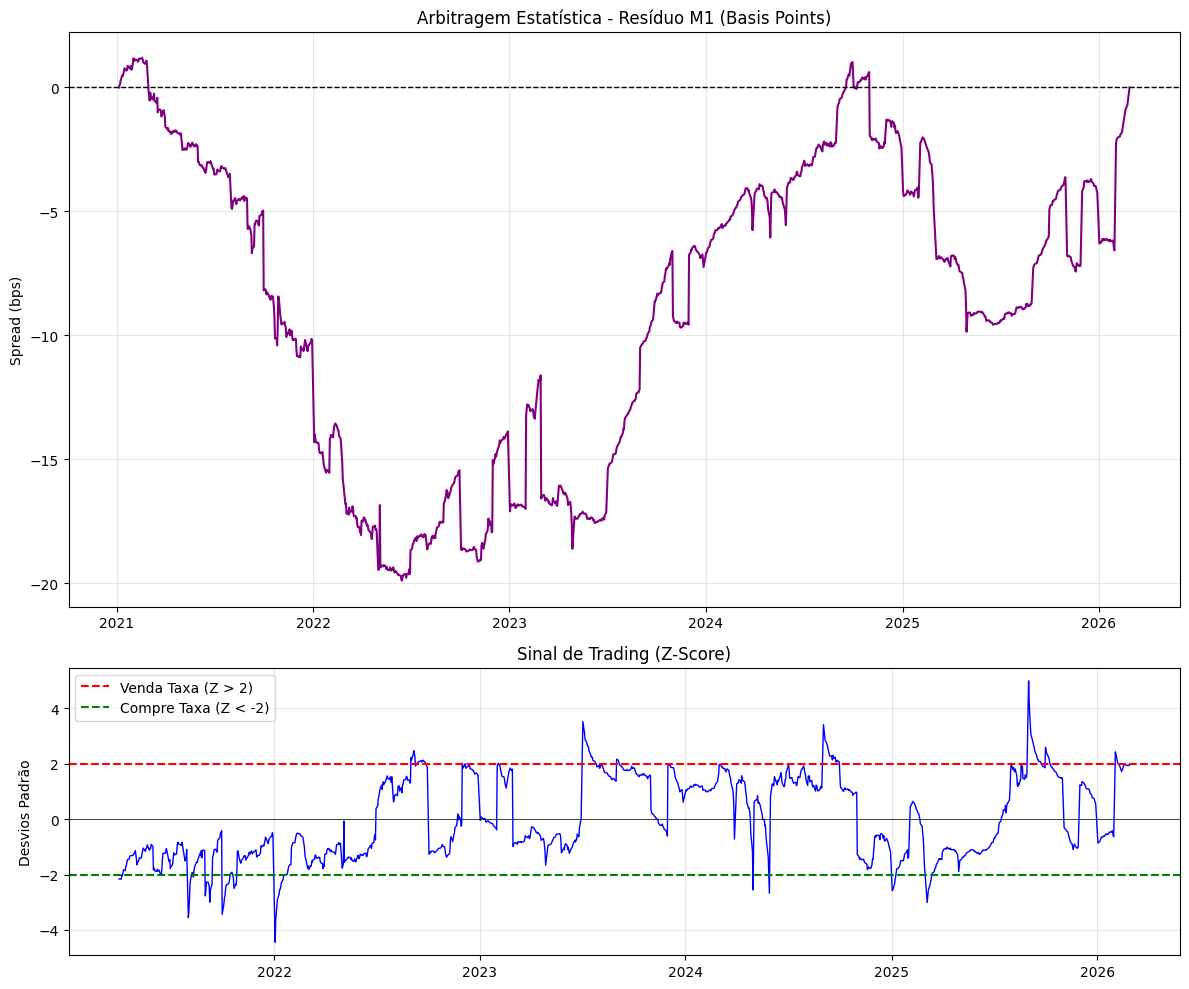

In [4]:
# EXTRAÇÃO DO RESÍDUO (A ANOMALIA)
print("Calculando o Preço Justo e extraindo o Spread...")
# Reconstruir variação teórica (usando APENAS os 3 fatores)
theo_diff = pca.inverse_transform(factors)
df_theo_diff = pd.DataFrame(theo_diff, index=df_diff.index, columns=df_diff.columns)

# Reconstruir a Taxa Teórica Acumulada
df_theo_rates = df_theo_diff.cumsum() + df_pca.iloc[0]

# Calcular o Spread (Real - Teórico)
df_real_rates = df_pca.iloc[1:]
df_spreads = df_real_rates - df_theo_rates

# Analisar o Vértice M5
vertice_alvo = 'M1'
spread_alvo = df_spreads[vertice_alvo]

# Z-Score (Janela Móvel de 60 dias)
window = 60
z_score = (spread_alvo - spread_alvo.rolling(window).mean()) / spread_alvo.rolling(window).std()

# Plotar Arbitragem (Gráfico 2)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [2, 1]})

ax1.plot(spread_alvo.index, spread_alvo.values * 100, color='purple', linewidth=1.5)
ax1.axhline(0, color='black', linestyle='--', linewidth=1)
ax1.set_title(f'Arbitragem Estatística - Resíduo {vertice_alvo} (Basis Points)')
ax1.set_ylabel('Spread (bps)')
ax1.grid(True, alpha=0.3)

ax2.plot(z_score.index, z_score.values, color='blue', linewidth=1)
ax2.axhline(2, color='red', linestyle='--', label='Venda Taxa (Z > 2)')
ax2.axhline(-2, color='green', linestyle='--', label='Compre Taxa (Z < -2)')
ax2.axhline(0, color='black', linewidth=0.5)
ax2.set_title('Sinal de Trading (Z-Score)')
ax2.set_ylabel('Desvios Padrão')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('Figures/arbitragem_spread.png')
plt.show()



In [5]:
# ORNSTEIN-UHLENBECK (TEMPO DE CORREÇÃO)
print(f"\n--- CALIBRAÇÃO ESTOCÁSTICA: {vertice_alvo} ---")
series = spread_alvo.dropna()

# Teste ADF (Estacionariedade)
adf_result = adfuller(series)
print(f"P-Value (ADF): {adf_result[1]:.4f}")
if adf_result[1] < 0.05:
    print("-> SÉRIE ESTACIONÁRIA! (Pode Operar)")
else:
    print("-> Série não estacionária a 95% (Aumente o histórico de dados).")

# Regressão OLS para achar Theta
y = series.diff().dropna()
X = series.shift(1).dropna()
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

theta = -model.params[vertice_alvo]
if theta > 0:
    half_life = np.log(2) / theta
    print(f"Velocidade de Reversão (Theta): {theta:.4f}")
    print(f"Meia-Vida (Half-Life): {half_life:.1f} dias úteis")
else:
    print("-> Erro: Theta negativo (série explosiva).")


--- CALIBRAÇÃO ESTOCÁSTICA: M1 ---
P-Value (ADF): 0.6425
-> Série não estacionária a 95% (Aumente o histórico de dados).
Velocidade de Reversão (Theta): 0.0025
Meia-Vida (Half-Life): 274.6 dias úteis


/tmp/ipykernel_1258581/4188966750.py:55: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


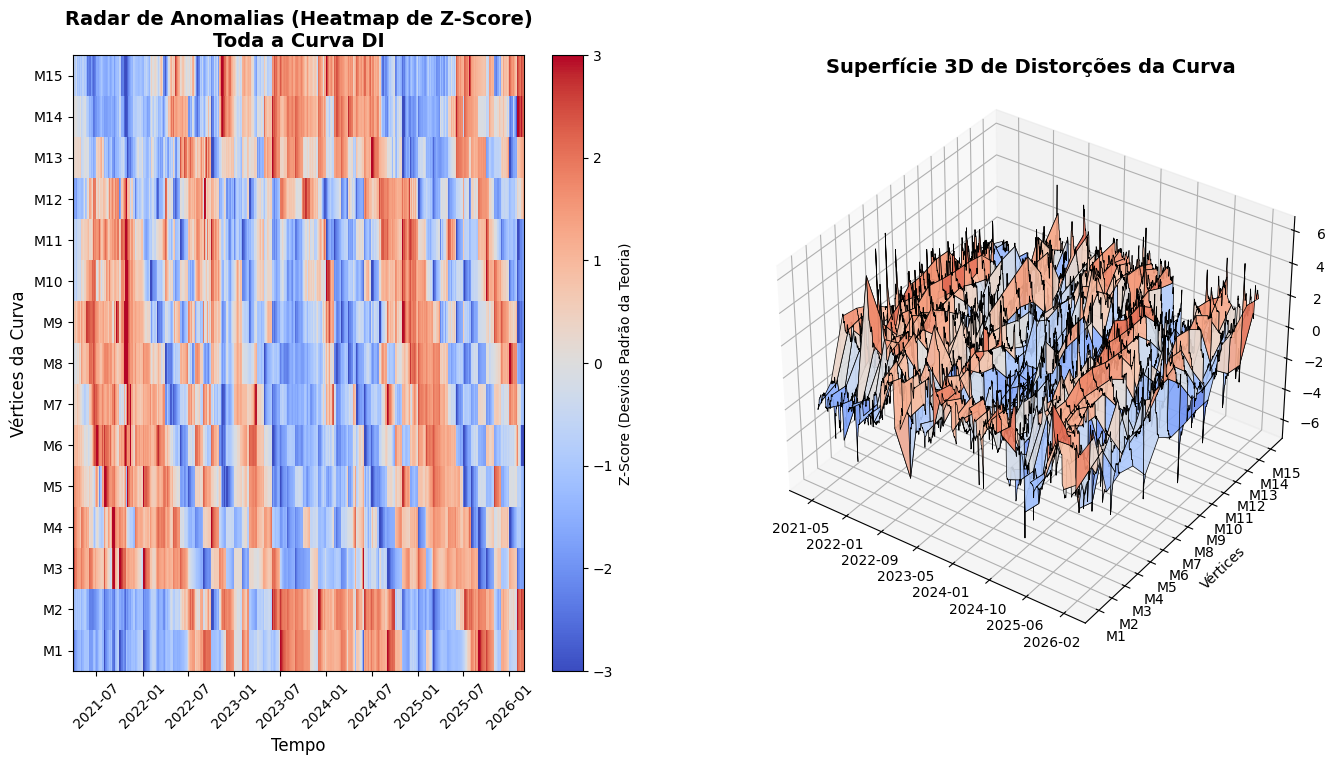

Superfície e Heatmap gerados com sucesso!


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


# 2. Calcular o Z-Score para TODOS os vértices ao mesmo tempo (O Radar completo)
window = 60
# Z = (Valor - Média da Janela) / Desvio Padrão da Janela
df_zscores = (df_spreads - df_spreads.rolling(window).mean()) / df_spreads.rolling(window).std()

# Limpar os NaNs gerados pela janela móvel inicial (os primeiros 60 dias)
df_z_clean = df_zscores.dropna()

# 3. Preparar os eixos para o gráfico 3D e Heatmap
# Eixo X = Datas, Eixo Y = Número do Vértice (1 a 15), Eixo Z = Valor do Z-Score
X_dates = df_z_clean.index
Y_verts = np.arange(1, len(df_z_clean.columns) + 1)
X, Y = np.meshgrid(mdates.date2num(X_dates), Y_verts)
Z = df_z_clean.T.values

# 4. Criar a figura com as duas visualizações (Lado a Lado)
fig = plt.figure(figsize=(16, 8))

# --- GRÁFICO 1: Heatmap (O Mapa de Calor da Mesa de Operações) ---
ax1 = fig.add_subplot(121)
# Usando cmap 'coolwarm': Vermelho = Z>0 (Venda), Azul = Z<0 (Compra)
im = ax1.pcolormesh(X_dates, Y_verts, Z, cmap='coolwarm', vmin=-3, vmax=3, shading='auto')
ax1.set_yticks(Y_verts)
ax1.set_yticklabels(df_z_clean.columns)
ax1.set_title('Radar de Anomalias (Heatmap de Z-Score)\nToda a Curva DI', fontsize=14, fontweight='bold')
ax1.set_ylabel('Vértices da Curva', fontsize=12)
ax1.set_xlabel('Tempo', fontsize=12)
# Formatar o eixo X para mostrar as datas bonitinhas
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)
fig.colorbar(im, ax=ax1, label='Z-Score (Desvios Padrão da Teoria)')

# --- GRÁFICO 2: Superfície 3D (A "Surface") ---
ax2 = fig.add_subplot(122, projection='3d')
surf = ax2.plot_surface(X, Y, Z, cmap='coolwarm', vmin=-3, vmax=3, linewidth=0.5, edgecolors='k', alpha=0.9)

# Ajustar eixos do 3D
ax2.set_yticks(Y_verts)
ax2.set_yticklabels(df_z_clean.columns)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax2.set_title('Superfície 3D de Distorções da Curva', fontsize=14, fontweight='bold')
ax2.set_ylabel('Vértices')
ax2.set_zlabel('Z-Score')

# Melhorar o ângulo de visão da superfície 3D (elevação e azimute)
ax2.view_init(elev=35, azim=-55)

# 5. Salvar e Mostrar
plt.tight_layout()
plt.savefig('Figures/superficie_arbitragem_final.png', dpi=300, bbox_inches='tight')
plt.show()

print("Superfície e Heatmap gerados com sucesso!")

In [7]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA

# 1. Carregar a matriz de taxas
# df_pivot = pd.read_csv("DI_Pivotado_Taxas_M1_M2.csv", index_col='Data_Referencia', parse_dates=True)
vertices = [f'M{i}' for i in range(1, 16)]
df_pca = df_pivot[vertices].dropna()

# 2. Separar o "Passado" (Treino) e o "Hoje" (O dia novo que queremos testar)
# Vamos fingir que o penúltimo dia foi o último fechamento, e a última linha é o "dia de hoje"
df_historico = df_pca.iloc[:-1]
dia_novo = df_pca.iloc[-1:]  # Última linha (ex: 2022-05-05)
data_hoje = dia_novo.index[0].strftime('%d/%m/%Y')

print(f"--- SIMULADOR DE MESA DE OPERAÇÕES ---")
print(f"Treinando o modelo com dados até o dia anterior...")
print(f"Analisando o pregão de hoje: {data_hoje}\n")

# 3. Treinar o modelo PCA apenas com o histórico
df_diff_hist = df_historico.diff().dropna()
pca = PCA(n_components=3)
pca.fit(df_diff_hist)

# 4. Reconstruir a história para ter a base do Z-Score
fatores_hist = pca.transform(df_diff_hist)
diff_teorica_hist = pca.inverse_transform(fatores_hist)
taxas_teoricas_hist = pd.DataFrame(diff_teorica_hist, index=df_diff_hist.index, columns=df_diff_hist.columns).cumsum() + df_historico.iloc[0]

spreads_hist = df_historico.iloc[1:] - taxas_teoricas_hist
media_spread_60d = spreads_hist.iloc[-60:].mean()  # Média móvel dos últimos 60 dias do histórico
std_spread_60d = spreads_hist.iloc[-60:].std()     # Desvio padrão dos últimos 60 dias

# 5. O ALGORITMO RODANDO "HOJE" (Tempo Real)
# A variação de hoje é a taxa de hoje menos a taxa de ontem
delta_y_hoje = dia_novo.values - df_historico.iloc[-1].values

# Calcular os 3 Fatores de hoje
fatores_hoje = pca.transform(delta_y_hoje)

# Reconstruir a variação matemática pura de hoje
delta_teorico_hoje = pca.inverse_transform(fatores_hoje)

# Taxa Teórica de Hoje = Taxa Real de Ontem + Variação Teórica de Hoje
taxa_teorica_hoje = df_historico.iloc[-1].values + delta_teorico_hoje

# Spread de Hoje = Taxa Real da B3 de Hoje - Taxa Teórica de Hoje
spread_hoje = dia_novo.values - taxa_teorica_hoje

# Z-Score de Hoje = (Spread Hoje - Média 60d do Passado) / Desvio 60d do Passado
z_score_hoje = (spread_hoje[0] - media_spread_60d.values) / std_spread_60d.values

# 6. Montar o Relatório do Radar
relatorio = pd.DataFrame({
    'Taxa B3 (%)': dia_novo.values[0],
    'Taxa Teórica (%)': taxa_teorica_hoje[0],
    'Spread (bps)': spread_hoje[0] * 100,
    'Z-Score': z_score_hoje
}, index=vertices)

# Identificar os sinais (O "Apito")
relatorio['Sinal'] = 'Neutro'
relatorio.loc[relatorio['Z-Score'] > 2, 'Sinal'] = '🔴 VENDA TAXA (CARO)'
relatorio.loc[relatorio['Z-Score'] < -2, 'Sinal'] = '🟢 COMPRA TAXA (BARATO)'

pd.set_option('display.float_format', '{:.3f}'.format)
print(relatorio)
print("\n=> RESUMO DOS APITOS DO RADAR:")
sinais_ativos = relatorio[relatorio['Sinal'] != 'Neutro']
if sinais_ativos.empty:
    print("Nenhum vértice superou 2 desvios padrão hoje. Mercado operando dentro da normalidade.")
else:
    for vertice, row in sinais_ativos.iterrows():
        print(f"ALERTA NO {vertice}: {row['Sinal']}! (Z-Score: {row['Z-Score']:.2f})")

--- SIMULADOR DE MESA DE OPERAÇÕES ---
Treinando o modelo com dados até o dia anterior...
Analisando o pregão de hoje: 27/02/2026

     Taxa B3 (%)  Taxa Teórica (%)  Spread (bps)  Z-Score  \
M1        14.900            14.898         0.220    2.044   
M2        14.730            14.703         2.702    2.417   
M3        13.577            13.602        -2.487   -1.850   
M4        13.679            13.687        -0.820   -1.393   
M5        13.508            13.521        -1.303   -1.586   
M6        13.487            13.488        -0.144   -3.205   
M7        13.396            13.405        -0.889   -1.315   
M8        13.207            13.218        -1.168   -2.074   
M9        12.969            12.976        -0.668   -2.007   
M10       12.841            12.847        -0.523   -1.773   
M11       12.647            12.647         0.043   -1.773   
M12       12.611            12.612        -0.165    1.128   
M13       12.399            12.390         0.905    1.435   
M14       12.25

/home/iara/miniconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
